# Trust 파트 — 신고 문항 라벨링 기반 분석 (정리본)

익명 투표 SNS 앱에서 신고를 받은 질문(카테고리별)의 패턴을 분석하고, 새 질문을 게시하기 전 위험도를 사전 검증할 수 있는 모델을 만드는 것을 목표로 한 분석이다. 이 노트북은 팀 내부용 전체 실험 기록에서 **최종 채택된 분석/모델만** 추려 정리한 버전이다.

## 핵심 요약

- **분석**: 카테고리별 신고 "구성비" 기준으로는 음주_폭력(85.7%)·외모_신체_비하(66.7%) 카테고리의 질문이 실제 안전신고를 받은 비율이 가장 높다. 질문당 신고건수 기준으로도 외모_신체_비하가 문항당 89.87건으로 압도적 1위다(문항 수가 15개로 적어 신고가 소수 문항에 집중된 영향이 크다). 신고자를 10개 학교 소속으로 한정해 노출 대비 신고율을 계산해도(표본 n=382, 참고용) 외모_신체_비하가 1.98건/1,000노출로 여전히 1위여서, 계산 방식이 다른 세 지표가 모두 같은 결론을 가리킨다. "그냥 싫어" 신고 뒤에도 실질적 안전 문제가 일부 섞여 있을 가능성을 문항 단위로 확인했다(예: 외모_신체_비하 15문항 중 단 2문항이 관련 "그냥 싫어" 690건의 71.6%를 차지).
- **모델링**: 카테고리 + 음절 n-gram(TF-IDF) 조합(ROC-AUC 0.603)이 가장 안정적이었고, 형태소 분석 기반 확정 키워드 하드룰과 결합한 하이브리드 방식을 채택했다.
- **운영 방침**: 이 모델은 완전 자동 차단용이 아니라, 사람이 검토할 항목의 우선순위를 정해주는 보조 도구로 운영하는 것을 제안한다. threshold=0.5 기준 전체 안전신고의 59.8%를 사전에 걸러낼 수 있지만, 게시된 질문 중에도 약 32.1%는 여전히 사후 신고로만 발견되는 잔여 위험이 있다.


## 사용하는 데이터

- `report_labeling_data/trust_question_review_all_labeled_clean.csv`: 팀 전체 라벨링 최종본 (question_id, question, label). **주의**: 동일 질문 텍스트가 서로 다른 question_id로 중복 존재하는 경우가 있어(`dup_question_text_review.csv` 참고), 이 파일의 `question_id` 컬럼에 `"521 | 1492"`처럼 여러 id가 `" | "`로 합쳐진 행이 121건 있다. 신고/노출 마트와 조인하려면 이 id들을 개별 행으로 분리(explode)해야 한다.
- `csv_export_v2/mart_safety_event_v2_clean.csv.gz`: 신고·차단·피드백 통합 마트(71,283행). `record_type` 4종 중 `QUESTION_FEEDBACK_OR_REPORT`(polls_questionreport 원천, 51,424건)가 질문 단위 신고/피드백 원본 이벤트다. `feedback_domain_rule_v1`(세부 사유 분류)와 `safety_interpretation_rule_v1`(POTENTIAL_SAFETY / PRODUCT_OR_RELATIONSHIP_FEEDBACK / POSITIVE_FEEDBACK / OTHER 4구간 해석)로 이미 규칙 기반 분류가 되어 있어, "신고=전부 안전 문제"로 뭉뚱그리지 않고 성격을 나눠볼 수 있다.
- `csv_export_v2/mart_question_exposure_clean.csv`: 질문세트×위치 grain(1,583,840행)의 노출 마트. `report_count` 컬럼은 실제로는 거의 다 0(99.99%, 실측치)이라 신뢰할 수 없어 신고 집계에는 쓰지 않았고, 대신 `piece_exists_flag==1`인 행 수를 question_id별로 세어 "질문이 세트에 배치된 횟수"를 노출 근사치로 사용한다.

두 마트 모두 `mart_safety_event`/`mart_question_exposure`(마트 v1) 대신 검증된 `_v2_clean` 버전을 사용한다.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.max_rows", None)

# 한글 폰트
import matplotlib
try:
    import koreanize_matplotlib  # noqa
except ImportError:
    matplotlib.rcParams["font.family"] = "AppleGothic"
matplotlib.rcParams["axes.unicode_minus"] = False

_candidates = [
    Path("csv_export_v2"),
    Path("project_4/csv_export_v2"),
    Path.home() / "Desktop" / "project_4" / "csv_export_v2",
]
DATA_DIR = next((c for c in _candidates if c.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("csv_export_v2 폴더를 찾지 못했습니다. DATA_DIR을 직접 지정해주세요.")
print(f"[OK] DATA_DIR = {DATA_DIR.resolve()}")

def load_mart(name: str, **kwargs) -> pd.DataFrame:
    for ext in (".csv.gz", ".csv"):
        p = DATA_DIR / f"{name}{ext}"
        if p.exists():
            return pd.read_csv(p, **kwargs)
    raise FileNotFoundError(f"{name} 마트를 {DATA_DIR}에서 찾지 못했습니다.")

[OK] DATA_DIR = /Users/soobinryu/Desktop/project_4/csv_export_v2


## 1. 카테고리별 신고 분석

### 1-1. 라벨 데이터 로드 및 정합성 확인

In [3]:
labeled = pd.read_csv("report_labeling_data/trust_question_review_all_labeled_clean.csv", dtype=str)
print("labeled shape:", labeled.shape)
print("중복 행:", labeled.duplicated().sum())
print("결측치:\n", labeled.isna().sum())
print()
print("label 분포:")
display(labeled["label"].value_counts())

labeled shape: (2964, 3)
중복 행: 0
결측치:
 question_id    0
question       0
label          0
dtype: int64

label 분포:


label
관계_호감_친밀도    598
성격_사회성       550
취향_일상        491
능력_재능        403
외모_신체_평가     321
연애           285
매력           192
학교_학업         89
음주_폭력         21
외모_신체_비하      14
Name: count, dtype: int64

In [4]:
# 팀 논의 결과 카테고리명 변경: "매력" -> "개성"
labeled["label"] = labeled["label"].replace({"매력": "개성"})
print("[OK] 카테고리명 변경 반영: 매력 -> 개성")
print(labeled["label"].value_counts())

[OK] 카테고리명 변경 반영: 매력 -> 개성
label
관계_호감_친밀도    598
성격_사회성       550
취향_일상        491
능력_재능        403
외모_신체_평가     321
연애           285
개성           192
학교_학업         89
음주_폭력         21
외모_신체_비하      14
Name: count, dtype: int64


In [5]:
# question_id가 " | "로 합쳐진 행(동일 질문 텍스트가 여러 id로 중복 존재하는 케이스) explode
exploded = labeled.assign(question_id=labeled["question_id"].str.split(r"\s*\|\s*")).explode("question_id")
exploded["question_id"] = exploded["question_id"].str.strip().astype(int)

print("explode 전:", labeled.shape[0], "행 / explode 후:", exploded.shape[0], "행")
assert exploded["question_id"].is_unique, "동일 question_id가 서로 다른 라벨에 중복 매핑되면 안 됨"
print("[OK] 모든 question_id가 고유 — 라벨 충돌 없음")

cat_map = exploded.set_index("question_id")["label"]

explode 전: 2964 행 / explode 후: 3088 행
[OK] 모든 question_id가 고유 — 라벨 충돌 없음


신고 마트와 조인하기 전, 라벨링된 2,964건 자체가 어떤 카테고리로 얼마나 분포하는지 먼저 본다. (신고 기록이 있는 질문만 모은 집합이라 서비스 전체 질문 분포는 아니지만, 어떤 유형의 질문이 신고 라벨링 대상으로 많이 걸렸는지는 보여준다.)

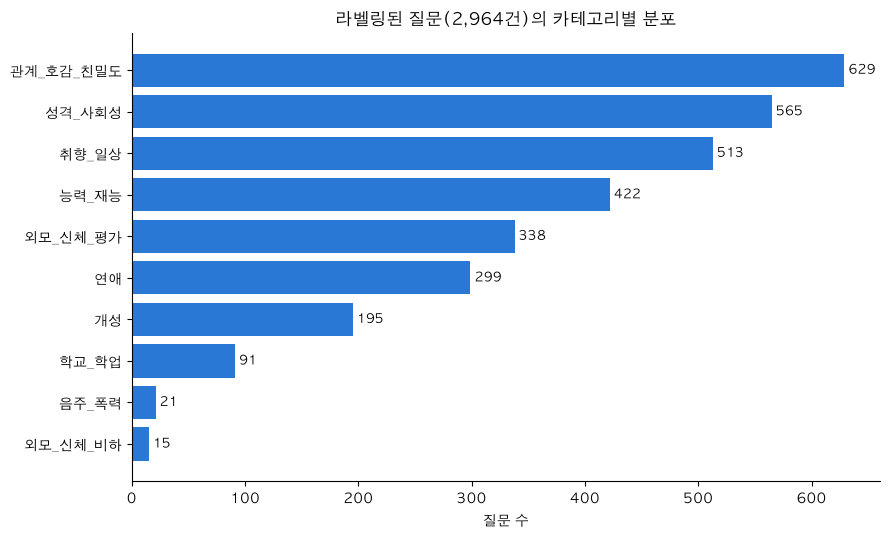

In [6]:
cat_counts = exploded.groupby("label").size().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(cat_counts.index, cat_counts.values, color="#2a78d6")
ax.set_xlabel("질문 수")
ax.set_title("라벨링된 질문(2,964건)의 카테고리별 분포")
for i, v in enumerate(cat_counts.values):
    ax.text(v, i, f" {v}", va="center", fontsize=9)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

### 1-2. 신고 데이터 로드 (mart_safety_event_v2)

In [34]:
safety = load_mart("mart_safety_event_v2_clean")
print("safety shape:", safety.shape)
print()
print("record_type 분포:")
display(safety["record_type"].value_counts())

# 질문 단위 신고/피드백 원본 이벤트만 사용 (polls_questionreport 원천)
reports = safety[safety["record_type"] == "QUESTION_FEEDBACK_OR_REPORT"].copy()
reports["question_id"] = reports["question_id"].astype(int)
reports["label"] = reports["question_id"].map(cat_map)

n_known = reports["label"].notna().sum()
n_unknown = reports["label"].isna().sum()
print(f"\n신고 이벤트 총 {len(reports):,}건 중 우리 라벨 데이터에 있는 질문: {n_known:,}건, 없는 질문: {n_unknown:,}건")
print("(신고는 있지만 라벨링 대상 2,964건에는 포함 안 된 질문 — 동일 질문 다른 question_id로 중복 존재하는 경우, 라벨링 대상 질문이 아닌 경우 등)")

reports_known = reports[reports["label"].notna()].copy()

safety shape: (71283, 41)

record_type 분포:


record_type
QUESTION_FEEDBACK_OR_REPORT    51424
USER_BLOCK                     19482
TIMELINE_REPORT                  208
PING_REPORT_COUNT_SNAPSHOT       169
Name: count, dtype: int64


신고 이벤트 총 51,424건 중 우리 라벨 데이터에 있는 질문: 50,926건, 없는 질문: 498건
(신고는 있지만 라벨링 대상 2,964건에는 포함 안 된 질문 — 동일 질문 다른 question_id로 중복 존재하는 경우, 라벨링 대상 질문이 아닌 경우 등)


### 1-3. 노출(배치) 횟수 계산 (mart_question_exposure)

**출처 확인**: 이 마트는 `final.polls_questionpiece` / `final.polls_questionset` 원본을 그대로 옮긴 것이다(SQL 빌드 스크립트에 원본 테이블 행 수와 마트 행 수가 정확히 일치하는지 확인하는 QA 쿼리가 포함되어 있음). 즉 owner(질문세트를 연 사람)가 10개 학교로 한정된 건 데이터를 추출할 때 표본을 뽑아서가 아니라, 이 앱의 "질문 세트 열기" 기능 자체가 원본 데이터상 이 10개 학교에서만 쓰였기 때문이다.


In [8]:
exposure = load_mart(
    "mart_question_exposure_clean",
    usecols=["question_id", "piece_exists_flag", "report_count"],
)
print("exposure shape:", exposure.shape)

# report_count 컬럼은 96.8%가 0이라 신뢰할 수 없음 — 신고 집계에 쓰지 않는 이유 확인
print("report_count가 0인 비율:", (exposure["report_count"].fillna(0) == 0).mean().round(3))

# piece_exists_flag==1(현재 존재하는 피스)인 행 수 = 질문이 세트에 배치된 횟수(노출 근사치)
exposure_count = exposure[exposure["piece_exists_flag"] == 1].groupby("question_id").size()
print("\n노출 근사치가 없는 라벨 질문 수:", exposure_count.reindex(cat_map.index).isna().sum(), "/", len(cat_map))

exposure shape: (1583840, 3)
report_count가 0인 비율: 1.0

노출 근사치가 없는 라벨 질문 수: 0 / 3088


### 1-4. 카테고리별 신고 요약

In [9]:
summary_rows = []
for cat, sub in exploded.groupby("label"):
    qids = sub["question_id"].astype(int)
    n_q = len(qids)
    n_reports = reports_known[reports_known["label"] == cat].shape[0]
    n_exposure = exposure_count.reindex(qids).sum()
    summary_rows.append({
        "카테고리": cat,
        "질문수": n_q,
        "신고건수": n_reports,
        "질문당_신고건수": round(n_reports / n_q, 2),
        "노출횟수(10개교 owner 기준)": int(n_exposure),
    })

report_summary = pd.DataFrame(summary_rows).sort_values("질문당_신고건수", ascending=False).reset_index(drop=True)
display(report_summary)


,카테고리,질문수,신고건수,질문당_신고건수,노출횟수(10개교 owner 기준)
0,외모_신체_비하,15,1348,89.87,6059
1,음주_폭력,21,662,31.52,16091
2,외모_신체_평가,338,7989,23.64,148725
3,개성,195,3787,19.42,99872
4,연애,299,5280,17.66,103700
5,능력_재능,422,6982,16.55,187515
6,성격_사회성,565,9050,16.02,250319
7,취향_일상,513,6881,13.41,133805
8,학교_학업,91,1201,13.20,38822
9,관계_호감_친밀도,629,7746,12.31,242176


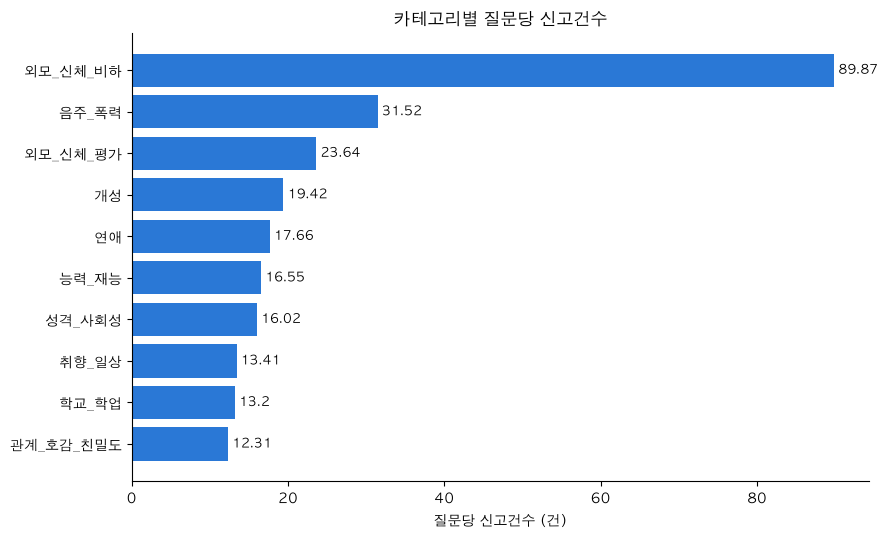

In [10]:
fig, ax = plt.subplots(figsize=(9, 5.5))
order = report_summary.sort_values("질문당_신고건수", ascending=True)
ax.barh(order["카테고리"], order["질문당_신고건수"], color="#2a78d6")
ax.set_xlabel("질문당 신고건수 (건)")
ax.set_title("카테고리별 질문당 신고건수")
for i, v in enumerate(order["질문당_신고건수"]):
    ax.text(v, i, f" {v}", va="center", fontsize=9)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


**참고**: `질문당_신고건수`(카테고리 내 질문 1개가 평균 몇 번 신고받았는지)는 카테고리마다 질문 수가 크게 다르다는 점(예: 관계_호감_친밀도 629문항 vs 외모_신체_비하 15문항)을 감안해서 봐야 한다. 노출(질문세트 배치 횟수) 대비 신고율은 신고자를 10개 학교 소속으로 한정한 참고용 지표를 이 섹션 마지막(1-7)에서 별도로 다룬다.


### 1-5. 신고 사유 성격 분해

신고 건수/신고율만으로는 "그냥 재미없어서"와 "안전 문제"가 섞여 보이므로, `mart_safety_event_v2`가 규칙 기반으로 이미 분류해둔 `feedback_domain_rule_v1`(세부 사유)과 `safety_interpretation_rule_v1`(POTENTIAL_SAFETY 여부 등)로 카테고리별 성격을 나눠본다.

In [11]:
print("=== feedback_domain_rule_v1 x 카테고리 (신고 건수) ===")
domain_ct = pd.crosstab(reports_known["label"], reports_known["feedback_domain_rule_v1"])
display(domain_ct)

print("\n=== safety_interpretation_rule_v1 x 카테고리 (행 기준 비율 %) ===")
interp_ct = pd.crosstab(reports_known["label"], reports_known["safety_interpretation_rule_v1"], normalize="index") * 100
display(interp_ct.round(1).sort_values("POTENTIAL_SAFETY", ascending=False))

=== feedback_domain_rule_v1 x 카테고리 (신고 건수) ===


feedback_domain_rule_v1,CONTENT_QUALITY,CONTENT_REPETITION,CONTENT_SAFETY,OTHER,PERSONAL_PREFERENCE,POSITIVE_FEEDBACK,RELATIONSHIP_FREQUENCY
label,,,,,,,
개성,62,201,530,53,2593,190,158
관계_호감_친밀도,62,475,520,100,5777,448,364
능력_재능,93,514,607,69,5293,210,196
성격_사회성,90,688,701,71,6883,324,293
연애,30,237,830,39,3778,168,198
외모_신체_비하,6,49,416,2,856,6,13
외모_신체_평가,102,410,1238,86,5636,306,211
음주_폭력,7,31,68,6,509,23,18
취향_일상,75,441,666,46,5360,101,192



=== safety_interpretation_rule_v1 x 카테고리 (행 기준 비율 %) ===


safety_interpretation_rule_v1,OTHER,POSITIVE_FEEDBACK,POTENTIAL_SAFETY,PRODUCT_OR_RELATIONSHIP_FEEDBACK
label,,,,
외모_신체_비하,0.1,0.4,30.9,68.5
연애,0.7,3.2,15.7,80.4
외모_신체_평가,1.1,3.8,15.5,79.6
개성,1.4,5.0,14.0,79.6
음주_폭력,0.9,3.5,10.3,85.3
취향_일상,0.7,1.5,9.7,88.2
능력_재능,1.0,3.0,8.7,87.3
성격_사회성,0.8,3.6,7.7,87.9
학교_학업,0.3,3.0,6.9,89.8


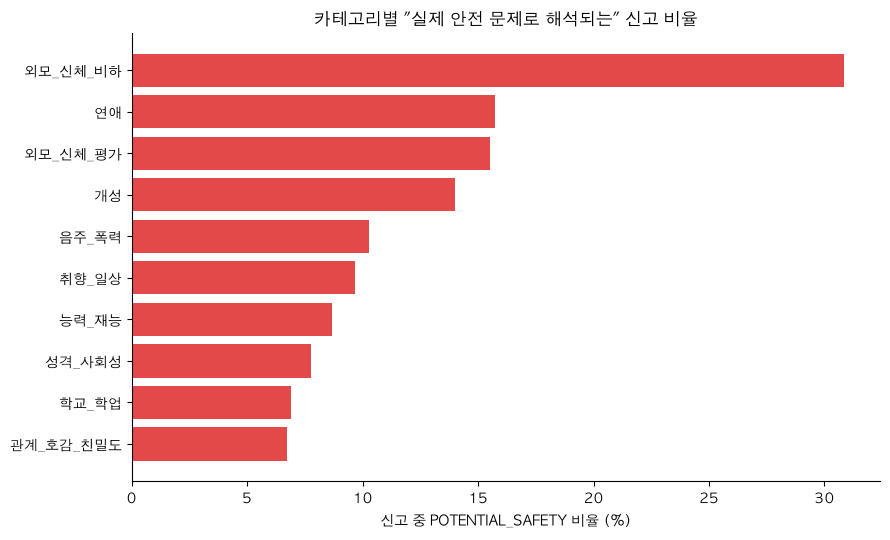

In [12]:
potential_safety_share = interp_ct["POTENTIAL_SAFETY"].sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(potential_safety_share.index, potential_safety_share.values, color="#e34948")
ax.set_xlabel("신고 중 POTENTIAL_SAFETY 비율 (%)")
ax.set_title("카테고리별 \"실제 안전 문제로 해석되는\" 신고 비율")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

### 1-5-보충. 부정 경험 3분류(Safety / Product Quality / Personalization)로 세부 분류

`safety_interpretation_rule_v1`은 4구간(POTENTIAL_SAFETY 등)으로 뭉뚱그려져 있어서, `trust_analysis.ipynb`(6번 섹션)에서 이미 만들어 둔 더 세밀한 3분류 — **Safety / Product Quality(질문 반복·오타 등 콘텐츠 품질) / Personalization(나와 안 맞음 등 개인화 실패)** — 를 그대로 재사용해서 카테고리별로 다시 본다. 매핑 기준(`feedback_domain_rule_v1` → 3분류)은 `trust_analysis.ipynb`와 완전히 동일하게 맞췄다 (아래 `SAFETY_DOMAINS`/`PRODUCT_QUALITY_DOMAINS`/`PERSONALIZATION_DOMAINS` 리스트 참고).

In [13]:
# trust_analysis.ipynb 6번 섹션과 동일한 매핑 (일관성 유지를 위해 그대로 재사용)
SAFETY_DOMAINS = ["CONTENT_SAFETY", "HARASSMENT", "MISINFORMATION", "SPAM", "ACCOUNT_INTEGRITY"]
PRODUCT_QUALITY_DOMAINS = ["CONTENT_QUALITY", "CONTENT_REPETITION"]
PERSONALIZATION_DOMAINS = ["PERSONAL_PREFERENCE", "RELATIONSHIP_MISMATCH", "RELATIONSHIP_FREQUENCY", "RELATIONSHIP_RELEVANCE"]
# 제외: POSITIVE_FEEDBACK(긍정 피드백), OTHER, PING_REPORT_SNAPSHOT(스냅샷 - 실시간 사건 아님)

def classify_domain(v):
    if v in SAFETY_DOMAINS:
        return "Safety"
    if v in PRODUCT_QUALITY_DOMAINS:
        return "Product Quality"
    if v in PERSONALIZATION_DOMAINS:
        return "Personalization"
    return "기타(긍정/기타)"

reports_known["trust_category"] = reports_known["feedback_domain_rule_v1"].map(classify_domain)
display(reports_known["trust_category"].value_counts())

trust_category
Personalization    39287
Safety              5659
Product Quality     3692
기타(긍정/기타)           2288
Name: count, dtype: int64

#### 카테고리별 신고 성격 구성 (카테고리 → 어떤 신고를 받았는지)

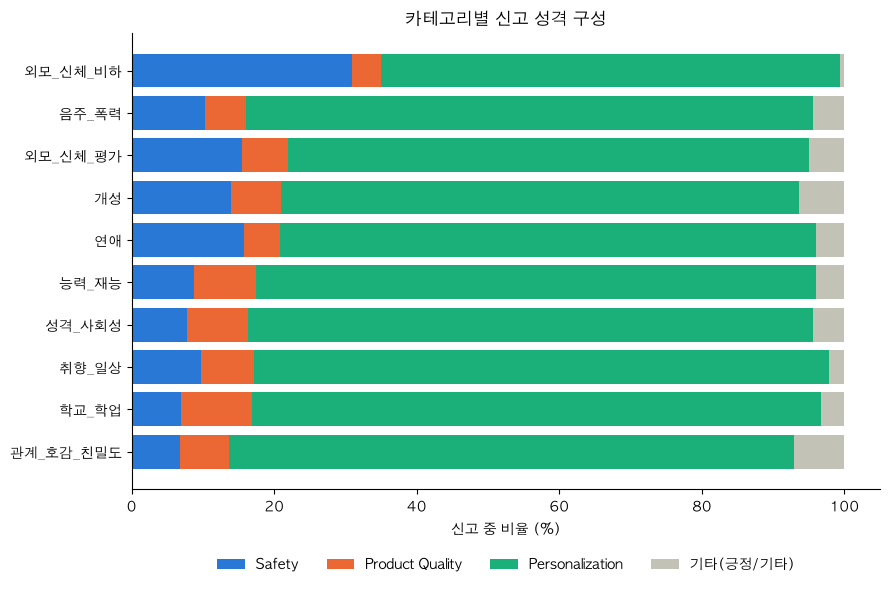

In [14]:
GROUP_COLORS = {
    "Safety": "#2a78d6",
    "Product Quality": "#eb6834",
    "Personalization": "#1baf7a",
    "기타(긍정/기타)": "#c3c2b7",
}
GROUP_ORDER = ["Safety", "Product Quality", "Personalization", "기타(긍정/기타)"]

cat_group_pct = pd.crosstab(reports_known["label"], reports_known["trust_category"], normalize="index")[GROUP_ORDER] * 100
cat_group_pct = cat_group_pct.loc[report_summary.sort_values("질문당_신고건수", ascending=True)["카테고리"]]

fig, ax = plt.subplots(figsize=(9, 6))
left = pd.Series(0, index=cat_group_pct.index, dtype=float)
for grp in GROUP_ORDER:
    ax.barh(cat_group_pct.index, cat_group_pct[grp], left=left, color=GROUP_COLORS[grp], label=grp)
    left += cat_group_pct[grp]
ax.set_xlabel("신고 중 비율 (%)")
ax.set_title("카테고리별 신고 성격 구성")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=4, frameon=False)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

#### 신고 성격별 카테고리 구성 (신고 종류 → 어떤 카테고리에서 많이 나왔는지)

반대 방향: Safety/Product Quality/Personalization 각각, 어떤 카테고리의 질문이 그 신고를 많이 받았는지 (카테고리 10개를 한 막대에 쌓으면 범례가 너무 많아져서, 신고 성격별로 패널을 나눠 그렸다).

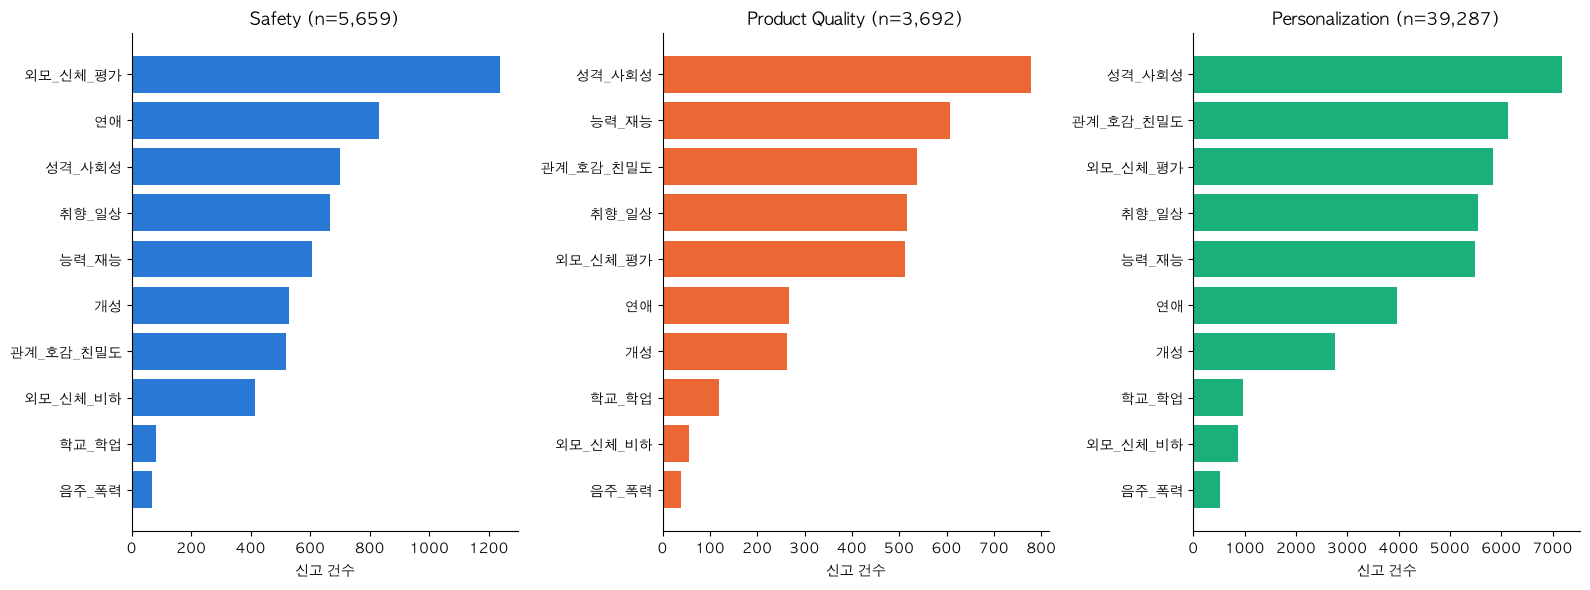

In [15]:
core_groups = ["Safety", "Product Quality", "Personalization"]
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharex=False)

for ax, grp in zip(axes, core_groups):
    sub = reports_known[reports_known["trust_category"] == grp]
    counts = sub["label"].value_counts().sort_values(ascending=True)
    ax.barh(counts.index, counts.values, color=GROUP_COLORS[grp])
    ax.set_title(f"{grp} (n={len(sub):,})")
    ax.set_xlabel("신고 건수")
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

### 1-5-보충2. "그냥 싫어" 사유 상세 확인

`reason_raw` 전체 분포를 보면 `"그냥 싫어"`가 28,446건(전체 신고의 55.3%)으로 압도적 1위다. 이 신고 사유를 고르는 화면이 실제로 어떻게 구성돼 있었는지(예: "그냥 싫어"가 첫 번째/기본 옵션으로 노출됐는지)는 앱 프론트엔드 코드에 접근할 수 없어 데이터만으로는 확인할 수 없다. 대신, **"안전 문제가 많은 카테고리일수록 사용자들이 '그냥 싫어'로 뭉뚱그리는 경향이 있는지"를 카테고리 간 비교로 간접 검증**해본다 — 만약 그렇다면 `POTENTIAL_SAFETY`(명시적 안전 사유) 기준만으로 타겟을 잡을 때 안전 문제가 실제보다 과소 집계될 위험이 있다.

In [16]:
reports_known["is_geunyang_sireo"] = reports_known["reason_raw"] == "그냥 싫어"
EXPLICIT_SAFETY_REASONS = ["불쾌한 질문 내용", "불쾌한 내용이 포함되어 있음", "선정적이거나 자극적인 질문"]
reports_known["is_explicit_safety"] = reports_known["reason_raw"].isin(EXPLICIT_SAFETY_REASONS)

reason_check = reports_known.groupby("label").agg(
    총신고=("reason_raw", "size"),
    그냥싫어_건=("is_geunyang_sireo", "sum"),
    명시적안전사유_건=("is_explicit_safety", "sum"),
).reset_index()
reason_check["그냥싫어_비율"] = (reason_check["그냥싫어_건"] / reason_check["총신고"] * 100).round(1)
reason_check["명시적안전사유_비율"] = (reason_check["명시적안전사유_건"] / reason_check["총신고"] * 100).round(1)
reason_check = reason_check.sort_values("명시적안전사유_비율", ascending=False)
display(reason_check)

print(f"전체 평균 '그냥 싫어' 비율: {reports_known['is_geunyang_sireo'].mean()*100:.1f}%")
print(f"전체 평균 명시적 안전 사유 비율: {reports_known['is_explicit_safety'].mean()*100:.1f}%")

,label,총신고,그냥싫어_건,명시적안전사유_건,그냥싫어_비율,명시적안전사유_비율
5,외모_신체_비하,1348,690,416,51.2,30.9
4,연애,5280,2992,830,56.7,15.7
6,외모_신체_평가,7989,4387,1238,54.9,15.5
0,개성,3787,1945,530,51.4,14.0
7,음주_폭력,662,389,68,58.8,10.3
8,취향_일상,6881,3833,666,55.7,9.7
2,능력_재능,6982,3851,607,55.2,8.7
3,성격_사회성,9050,4802,701,53.1,7.7
9,학교_학업,1201,618,83,51.5,6.9
1,관계_호감_친밀도,7746,4660,520,60.2,6.7


전체 평균 '그냥 싫어' 비율: 55.3%
전체 평균 명시적 안전 사유 비율: 11.1%


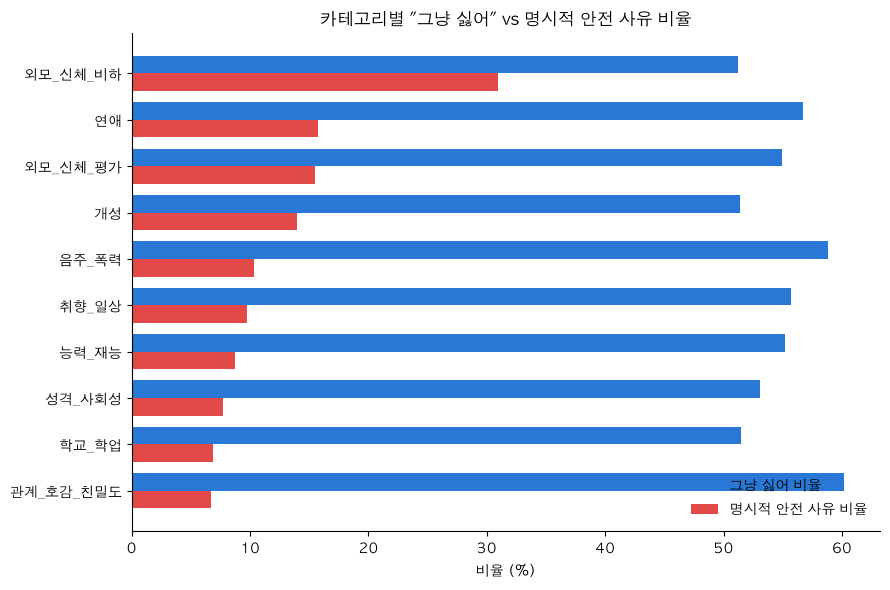

In [17]:
order = reason_check.sort_values("명시적안전사유_비율", ascending=True)["label"]
plot_df = reason_check.set_index("label").loc[order]

fig, ax = plt.subplots(figsize=(9, 6))
y = range(len(plot_df))
bar_h = 0.38
ax.barh([i + bar_h/2 for i in y], plot_df["그냥싫어_비율"], height=bar_h, color="#2a78d6", label="그냥 싫어 비율")
ax.barh([i - bar_h/2 for i in y], plot_df["명시적안전사유_비율"], height=bar_h, color="#e34948", label="명시적 안전 사유 비율")
ax.set_yticks(list(y))
ax.set_yticklabels(plot_df.index)
ax.set_xlabel("비율 (%)")
ax.set_title('카테고리별 "그냥 싫어" vs 명시적 안전 사유 비율')
ax.legend(loc="lower right", frameon=False)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

**관찰**: "그냥 싫어" 비율은 카테고리와 거의 무관하게 51~60% 사이(전체 평균 55.3%)로 굉장히 일정하다. 반면 명시적 안전 사유 비율은 외모_신체_비하(30.9%)가 압도적으로 높고 나머지는 6.7~15.7%로 큰 차이를 보인다. 오히려 명시적 안전 사유 비율이 높은 카테고리(외모_신체_비하·연애·외모_신체_평가·개성)일수록 "그냥 싫어" 비율은 평균보다 살짝 낮은 경향도 보인다.

즉, **"그냥 싫어"가 안전 문제를 대량으로 가리고 있다는 근거는 약해 보인다** — 사용자들이 실제로는 사유를 구분해서 고르고 있고, 안전 문제일수록 오히려 명시적 사유를 더 정확히 선택하는 경향이 데이터에 나타난다. 다만 "그냥 싫어" 안에도 소수의 진짜 안전 관련 불만이 섞여 있을 가능성 자체를 완전히 배제할 수는 없다(문항 텍스트를 다 읽어보지 않는 한). 모델링(2번)에서는 일단 `POTENTIAL_SAFETY`(명시적 안전 사유) 기준을 타겟으로 진행하되, 이 한계는 명시해둔다.


**추가 관찰(상관관계)**: "그냥 싫어" 비율과 명시적 안전 사유 비율의 카테고리 간 상관계수는 **-0.40**(중간 정도의 음의 상관)으로, 명시적 안전 사유 비율이 높은 카테고리일수록 "그냥 싫어" 비율이 낮아지는 경향이 실제로 존재한다. 다만 두 지표의 "카테고리 간 변동폭"을 비교하면 훨씬 흥미로운 그림이 나온다 — **명시적 안전 사유 비율은 카테고리에 따라 최대 4.6배(6.7%→30.9%) 차이**가 나는 반면, **"그냥 싫어" 비율은 최대 1.18배(51.2%→60.2%)밖에 차이 나지 않는다.** 즉 "그냥 싫어"는 카테고리가 무엇이든 신고자의 절반 이상이 거의 항상 고르는 일종의 기본값(default) 클릭에 가깝고, 콘텐츠가 실제로 얼마나 위험한지에 대해 훨씬 더 민감하게 반응하는 건 명시적 안전 사유 쪽이다 — 그래서 카테고리별 위험도를 비교할 땐 "그냥 싫어" 비율보다 명시적 안전 사유 비율(또는 POTENTIAL_SAFETY 비율)을 기준으로 삼는 게 더 타당하다.

참고로 전체 10개 카테고리 중 질문 수가 가장 많은(629건) **관계_호감_친밀도**가 "그냥 싫어" 비율은 가장 높고(60.2%) 명시적 안전 비율은 가장 낮다(6.7%) — 가장 대중적인 유형의 질문일수록 안전 문제가 실제로 드물다는, 상식과 부합하는 참조점으로 볼 수 있다.

### 1-5-보충3. 외모_신체_비하 — "그냥 싫어" 690건, 문항별로 쪼개보기

카테고리 평균만 보면 외모_신체_비하의 "그냥 싫어" 비율(51.2%)이 오히려 10개 카테고리 중 가장 낮아서 "안전 문제가 그냥 싫어에 가려져 있다"는 근거가 약해 보인다. 하지만 이 카테고리는 라벨링된 문항이 15개뿐이라, 평균 비율 뒤에 극소수 문항으로의 쏠림이 숨어 있을 수 있다 — 문항 단위로 직접 확인한다.

In [18]:
sub = reports_known[reports_known["label"] == "외모_신체_비하"]
qtext = exploded.set_index("question_id")["question"]

per_q = sub.groupby("question_id").agg(
    총신고=("reason_raw", "size"),
    그냥싫어=("is_geunyang_sireo", "sum"),
    명시적안전=("is_explicit_safety", "sum"),
).reset_index()
per_q["question"] = per_q["question_id"].map(qtext)
per_q["그냥싫어_비율"] = (per_q["그냥싫어"] / per_q["총신고"] * 100).round(1)
per_q = per_q.sort_values(["총신고", "question_id"], ascending=[False, True])  # 동점 시 question_id로 타이브레이크(재현성 확보)

top2_share = per_q.head(2)["그냥싫어"].sum() / per_q["그냥싫어"].sum() * 100
print(f"상위 2개 문항이 카테고리 전체 '그냥 싫어' 690건 중 {top2_share:.1f}%를 차지")
display(per_q[["question_id", "question", "총신고", "그냥싫어", "명시적안전", "그냥싫어_비율"]])

상위 2개 문항이 카테고리 전체 '그냥 싫어' 690건 중 71.6%를 차지


,question_id,question,총신고,그냥싫어,명시적안전,그냥싫어_비율
0,410,발냄새가 호두과자 냄새일 것 같은 사람은?,803,383,289,47.7
1,416,발가락에서 페브리즈향이 날 것 같은 사람은?,205,111,57,54.1
2,470,발가락이 귀여울 것 같은 친구는?,154,81,38,52.6
3,570,웃는 모습이 제일 웃긴 사람은?,91,59,18,64.8
4,1035,사진빨을 잘받는 사람은?,38,20,4,52.6
5,1524,얼굴을 가장 막 쓰는 사람은?,27,17,4,63.0
6,2463,사진빨 잘 받는 친구는?,7,4,0,57.1
7,2559,발에서 블루베리 향 날 것 같은 사람은?,6,4,1,66.7
8,3345,아바타 닮은 것 같은 사람은?,5,4,1,80.0
12,4047,퀸동주가 롤모델일 것 같은 사람은?,4,2,2,50.0


**관찰**: "그냥 싫어" 690건 중 71.6%가 문항 딱 2개(410 "발냄새가 호두과자 냄새일 것 같은 사람은?", 416 "발가락에서 페브리즈향이 날 것 같은 사람은?")에서 나왔다 — 둘 다 표면적으로는 욕설/비하 단어가 없지만 냄새를 빗대 놀리는 유형으로, 처음 문항 리뷰 때 지목했던 "겉으로는 비하가 아니지만 기분 나쁠 수 있는" 케이스와 정확히 겹친다.

다만 이 두 문항 자체의 명시적 안전 사유 비율(각각 36.0%, 27.8%)은 카테고리 평균(30.9%)과 비슷하거나 오히려 높은 편이라, "이 두 문항만 유독 안전 사유가 그냥 싫어에 가려졌다"고 단정하기는 어렵다. 더 정확히는 **노출이 압도적으로 많았던 두 문항이 두 신고 유형(그냥 싫어/명시적 안전) 모두를 절대량으로 크게 끌어올린 것**에 가깝다 — reason_raw 코드만으로는 690건 각각이 진짜 취향 문제인지 완곡한 안전 불만인지 확정할 수 없다는 한계는 여전히 남는다.

### 1-5-보충4. 음주_폭력 — 문항별 신고 분해

외모_신체_비하와 같은 방식으로 음주_폭력(21문항)도 문항 단위로 쪼개서, 신고가 특정 문항에 쏠려 있는지 확인한다.

In [19]:
sub2 = reports_known[reports_known["label"] == "음주_폭력"]

per_q2 = sub2.groupby("question_id").agg(
    총신고=("reason_raw", "size"),
    그냥싫어=("is_geunyang_sireo", "sum"),
    명시적안전=("is_explicit_safety", "sum"),
).reset_index()
per_q2["question"] = per_q2["question_id"].map(qtext)
per_q2["그냥싫어_비율"] = (per_q2["그냥싫어"] / per_q2["총신고"] * 100).round(1)
per_q2 = per_q2.sort_values(["총신고", "question_id"], ascending=[False, True])  # 동점 시 question_id로 타이브레이크(재현성 확보)

top2_share2 = per_q2.head(2)["그냥싫어"].sum() / per_q2["그냥싫어"].sum() * 100
print(f"상위 2개 문항이 카테고리 전체 그냥싫어 {int(per_q2['그냥싫어'].sum())}건 중 {top2_share2:.1f}%를 차지 (참고: 외모_신체_비하는 71.6%)")
display(per_q2[["question_id", "question", "총신고", "그냥싫어", "명시적안전", "그냥싫어_비율"]])

상위 2개 문항이 카테고리 전체 그냥싫어 389건 중 20.6%를 차지 (참고: 외모_신체_비하는 71.6%)


,question_id,question,총신고,그냥싫어,명시적안전,그냥싫어_비율
5,478,범죄현장을 지나다가 억울하게 발자국을 남길 것 같은 사람은?,88,43,8,48.9
0,224,나중에 술을 제일 잘 마실거 같은 사람은?,65,37,3,56.9
2,334,술을 제일 잘 마실거 같은 사람은?,65,31,12,47.7
4,435,패싸움이 났을 때 제일 먼저 부르고 싶은 사람은?,59,34,8,57.6
1,225,나 대신 흑기사를 해줄 것 같은 사람은?,52,26,2,50.0
3,420,"성인이 되고, 술이 제일 셀것 같은 사람은?",50,29,4,58.0
6,530,나중에 술한잔 둘이서 하고 싶은 친구는?,42,31,1,73.8
16,1545,게임하면서 지면 샷건 날려서 책상 뽀개먹을 것 같은 사람은?,40,22,8,55.0
15,1541,어른돼서 가장 술찌일 것 같은 사람,37,21,6,56.8
7,680,"나중에 술에 취해 ""자니...?""라고 보낼 것 같은 사람은?",24,18,2,75.0


**관찰**: 음주_폭력은 외모_신체_비하와 대조적으로 신고가 21개 문항 전체에 비교적 고르게 퍼져 있다 — 상위 2개 문항이 차지하는 "그냥 싫어" 비중이 20.6%에 불과하다(외모_신체_비하는 71.6%). 21문항 전부 신고 이력이 있고, 술/폭력을 직접 언급하는 문항(예: "술을 제일 잘 마실거 같은 사람은?", "패싸움이 났을 때 제일 먼저 부르고 싶은 사람은?")이 소수 문항에 몰리지 않고 골고루 신고를 받았다는 뜻이다.

이는 이전에 함께 확인했던 내용과 일치한다 — 음주_폭력은 문항 대부분이 표면적으로도 명확하게 부적절(술/폭력 직접 언급)해서 어떤 문항이든 비슷한 비율로 문제 제기가 들어오는 반면, 외모_신체_비하는 소수의 "표면적으로는 애매한" 문항(냄새 관련 등)에 신고가 집중된다 — 그래서 음주_폭력은 하드 룰(키워드 기반) 방식이 잘 통하고, 외모_신체_비하는 문항 단위 사람 검수가 더 필요하다는 4-1의 결론과도 이어진다.

### 1-6. 1차 관찰 결과 (검증 필요)

- **질문 단위로 "안전신고를 한 번이라도 받은 비율"은 음주_폭력(85.7%)이 가장 높고, 외모_신체_비하(66.7%)가 2위, 연애(51.2%)가 3위다** — 다만 음주_폭력은 문항 수 자체가 21개로 적어서, 주제 특성상 있으면 거의 다 한 번은 신고를 받는다는 의미에 가깝고 신고 "양"이 많다는 뜻은 아니다(총 신고건수는 662건). 반대로 **외모_신체_비하**는 질문당 신고건수(89.87건, 1위), 노출 대비 신고율(신고자도 10개 학교로 맞춘 값 기준 1.98건/1,000노출, 1위, 표본 n=382로 작아 참고용), POTENTIAL_SAFETY 비율(30.9%, 1위)까지 나머지 지표에서는 모두 1위다. 신고의 "양"과 "심각도"를 종합하면 외모_신체_비하 쪽이 더 위험도가 높다고 본다.
- **POTENTIAL_SAFETY 비율**(신고 건수 기준)도 외모_신체_비하가 30.9%로 가장 높고, 그 다음이 연애(15.7%)·외모_신체_평가(15.5%)·개성(14.0%) 순 — 신고를 많이 받는 것과, 그 신고가 "진짜 안전 문제"로 해석되는 것은 다른 축이라는 점은 여전히 유효.
- 반대로 **관계_호감_친밀도·성격_사회성·취향_일상·학교_학업**은 여러 지표에서 공통적으로 낮게 나타나, 신고가 있어도 대부분 "그냥 취향에 안 맞음(PERSONAL_PREFERENCE)" 성격에 가깝다.


### 1-7. 노출 대비 신고율 (10개 학교 한정, 참고용)

`노출`(질문세트 배치 횟수)은 owner가 10개 학교로 한정된 원본 데이터이므로, 신고율을 계산하려면 분자(신고)도 신고자가 10개 학교 소속인 것만 써야 모집단이 맞는다. 이렇게 좁히면 전체 신고 50,926건 중 382건(0.8%)만 남는다 — 표본이 매우 작아서(카테고리별로 3~73건) 메인 지표로 쓰기보다는 경향 참고용으로만 본다.


신고자도 10개 학교 소속인 신고: 382건 / 전체 50,926건 (0.8%)


,카테고리,노출횟수(10개교),신고건수(신고자도 10개교),신고율_per_1000노출(10개교 통일)
0,외모_신체_비하,6059,12,1.98
1,외모_신체_평가,148725,67,0.45
2,연애,103700,35,0.34
3,개성,99872,33,0.33
4,성격_사회성,250319,81,0.32
5,능력_재능,187515,55,0.29
6,취향_일상,133805,35,0.26
7,관계_호감_친밀도,242176,54,0.22
8,음주_폭력,16091,3,0.19
9,학교_학업,38822,7,0.18


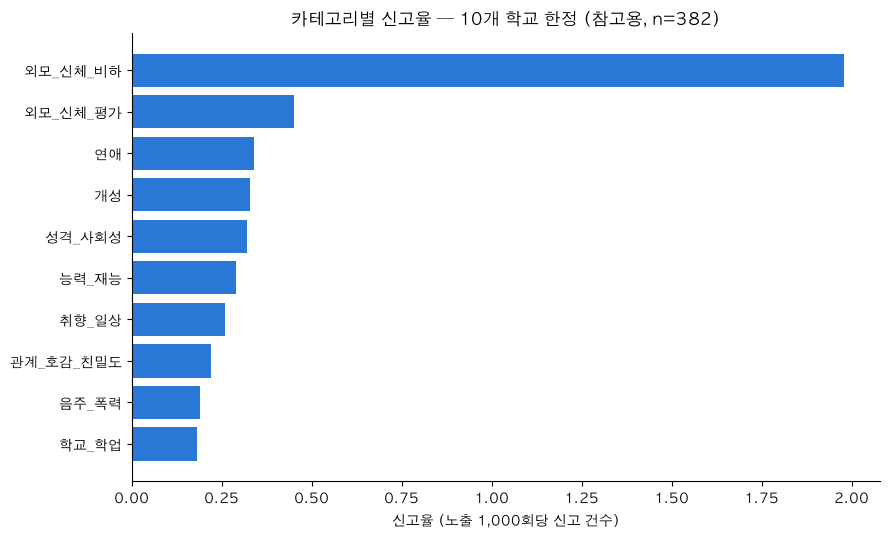

In [20]:
TEN_SCHOOLS = [1719, 5520, 4426, 5491, 369, 271, 4516, 5372, 1478, 352]

actor_prof = load_mart(
    "mart_user_acquisition_profile_v2_clean",
    usecols=["user_id", "current_school_id"],
    dtype={"user_id": "int64", "current_school_id": "string"},  # dtype을 미리 지정해서
    # pandas가 컬럼 타입을 추론하다 mixed-type 경고를 만드는 과정에서 나는 내부 버그(IndexError)를 피한다
)
# current_school_id가 "\N"(결측) 섞인 문자열 컬럼이라 그냥 isin()하면 판다스 버전에 따라
# 숫자로 된 값과 안 매칭되거나(과소집계) 파싱 에러가 날 수 있어 명시적으로 숫자 변환한다.
actor_prof["current_school_id"] = pd.to_numeric(actor_prof["current_school_id"], errors="coerce")
actor_prof = actor_prof.rename(columns={"user_id": "actor_user_id", "current_school_id": "actor_school_id"})
reports_known_10 = reports_known.merge(actor_prof, on="actor_user_id", how="left")
reports_known_10 = reports_known_10[reports_known_10["actor_school_id"].isin(TEN_SCHOOLS)]

print(f"신고자도 10개 학교 소속인 신고: {len(reports_known_10):,}건 / 전체 {len(reports_known):,}건"
      f" ({len(reports_known_10)/len(reports_known)*100:.1f}%)")

rate_rows = []
for cat, sub in exploded.groupby("label"):
    qids = sub["question_id"].astype(int)
    n_exposure = exposure_count.reindex(qids).sum()
    n_reports_10 = reports_known_10[reports_known_10["label"] == cat].shape[0]
    rate_rows.append({
        "카테고리": cat,
        "노출횟수(10개교)": int(n_exposure),
        "신고건수(신고자도 10개교)": n_reports_10,
        "신고율_per_1000노출(10개교 통일)": round(n_reports_10 / n_exposure * 1000, 2) if n_exposure else float("nan"),
    })
rate_10 = pd.DataFrame(rate_rows).sort_values("신고율_per_1000노출(10개교 통일)", ascending=False).reset_index(drop=True)
display(rate_10)

fig, ax = plt.subplots(figsize=(9, 5.5))
order = rate_10.sort_values("신고율_per_1000노출(10개교 통일)", ascending=True)
ax.barh(order["카테고리"], order["신고율_per_1000노출(10개교 통일)"], color="#2a78d6")
ax.set_xlabel("신고율 (노출 1,000회당 신고 건수)")
ax.set_title("카테고리별 신고율 — 10개 학교 한정 (참고용, n=382)")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


## 2. 신고(안전) 예측 모델링

**목표**: 질문 텍스트/카테고리만 보고, 이 질문이 나중에 **안전 관련 신고(명시적 안전 사유)** 를 받을 가능성이 높은지 사전에 걸러낼 수 있는지 확인한다.

**타겟 정의**: 라벨링된 3,088개 질문(question_id 기준) 각각에 대해, 그 질문이 받은 신고들 중 명시적 안전 사유(`불쾌한 질문 내용`/`불쾌한 내용이 포함되어 있음`/`선정적이거나 자극적인 질문`)가 **1건이라도 있으면 1**, 없으면 0. (1-5-보충에서 만든 `reports_known`을 그대로 재사용한다.)

**왜 "신고 1건이라도 있으면 위험"이 아니라 이 기준인지**: 1-5-보충2에서 확인했듯 전체 신고의 55%가 "그냥 싫어"(단순 취향 문제)라, 신고 여부 자체를 타겟으로 잡으면 모델이 사실상 "취향에 안 맞는 질문"을 맞히는 모델이 돼버린다. 안전 문제만 따로 걸러내는 게 원래 목적에 맞다.

In [21]:
q_level = reports_known.groupby("question_id")["is_explicit_safety"].sum().reindex(exploded["question_id"]).fillna(0)
q_level = q_level.to_frame("n_safety_reports").reset_index()
q_level["label"] = q_level["question_id"].map(cat_map)
q_level["question"] = q_level["question_id"].map(exploded.set_index("question_id")["question"])
q_level["has_safety_report"] = (q_level["n_safety_reports"] > 0).astype(int)

print("질문 수:", len(q_level))
print(f"has_safety_report=1 비율: {q_level['has_safety_report'].mean():.1%}  (전체 대비 비교적 균형 잡힌 편)")
display(q_level.groupby("label")["has_safety_report"].agg(["sum", "count", "mean"]).sort_values("mean", ascending=False))

질문 수: 3088
has_safety_report=1 비율: 39.8%  (전체 대비 비교적 균형 잡힌 편)


,sum,count,mean
label,,,
음주_폭력,18,21,0.857143
외모_신체_비하,10,15,0.666667
연애,153,299,0.511706
외모_신체_평가,157,338,0.464497
개성,81,195,0.415385
학교_학업,37,91,0.406593
성격_사회성,223,565,0.394690
관계_호감_친밀도,241,629,0.383148
취향_일상,172,513,0.335283


### 2-1. 피처 설계 및 모델

- **카테고리**: 원-핫 인코딩 (10개 라벨)
- **질문 텍스트**: TF-IDF, 음절 n-gram(2~3자) 기반 — 한국어 형태소 분석기(예: konlpy/mecab)가 설치돼 있지 않아 띄어쓰기 기준 단어 분리 대신 음절 단위로 처리. 데이터가 3,088건으로 크지 않아서 `min_df=10`(최소 10번 이상 등장한 n-gram만)으로 제한해 과적합을 줄임
- **모델**: 로지스틱 회귀 (`class_weight="balanced"`, `C=0.5`) — 해석 가능하고 소규모 데이터에 적합
- **평가**: 데이터가 작아 한 번의 train/test 분할보다 **5-fold 교차검증 평균 ROC-AUC**를 기본 지표로 사용

In [22]:
try:
    import sklearn
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn"])
    import sklearn
print("scikit-learn:", sklearn.__version__)

scikit-learn: 1.9.1


In [23]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

X = q_level[["label", "question"]]
y = q_level["has_safety_report"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

prep_full = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["label"]),
    ("text", TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 3), max_features=300, min_df=10), "question"),
])
pipe_full = Pipeline([("prep", prep_full), ("clf", LogisticRegression(max_iter=2000, C=0.5, class_weight="balanced"))])

prep_cat = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), ["label"])])
pipe_cat = Pipeline([("prep", prep_cat), ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))])

cv_full = cross_val_score(pipe_full, X, y, cv=5, scoring="roc_auc")
cv_cat = cross_val_score(pipe_cat, X, y, cv=5, scoring="roc_auc")

print(f"카테고리만 모델      5-fold CV ROC-AUC: {cv_cat.mean():.3f} (+/-{cv_cat.std():.3f})")
print(f"카테고리+텍스트 모델  5-fold CV ROC-AUC: {cv_full.mean():.3f} (+/-{cv_full.std():.3f})")
print("(참고: ROC-AUC 0.5 = 랜덤 추측 수준, 1.0 = 완벽한 분류)")

카테고리만 모델      5-fold CV ROC-AUC: 0.564 (+/-0.025)
카테고리+텍스트 모델  5-fold CV ROC-AUC: 0.603 (+/-0.026)
(참고: ROC-AUC 0.5 = 랜덤 추측 수준, 1.0 = 완벽한 분류)


### 2-2. 최종 모델(카테고리+텍스트) 상세 평가

In [24]:
pipe_full.fit(X_train, y_train)
pred = pipe_full.predict(X_test)
proba = pipe_full.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred, digits=3, target_names=["안전신고 없음(0)", "안전신고 있음(1)"]))
print("holdout ROC-AUC:", round(float(roc_auc_score(y_test, proba)), 3))
print("\nconfusion matrix (행=실제, 열=예측):")
print(confusion_matrix(y_test, pred))

print(f"\n참고: 아무것도 안 걸러내고 전부 '안전신고 없음'으로 찍는 다수결 기준 정확도: {(y_test == 0).mean():.3f}"
      f" / 모델 정확도: {(pred == y_test).mean():.3f}")

              precision    recall  f1-score   support

  안전신고 없음(0)      0.679     0.562     0.615       372
  안전신고 있음(1)      0.474     0.598     0.529       246

    accuracy                          0.576       618
   macro avg      0.576     0.580     0.572       618
weighted avg      0.597     0.576     0.581       618

holdout ROC-AUC: 0.623

confusion matrix (행=실제, 열=예측):
[[209 163]
 [ 99 147]]

참고: 아무것도 안 걸러내고 전부 '안전신고 없음'으로 찍는 다수결 기준 정확도: 0.602 / 모델 정확도: 0.576


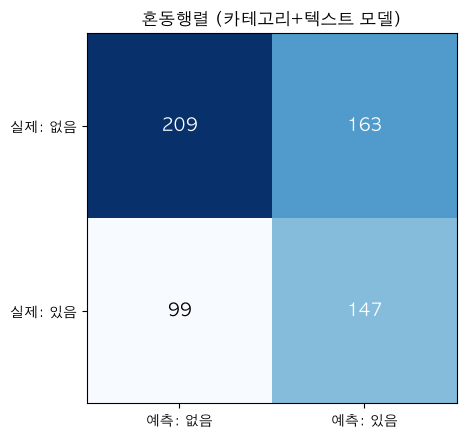

In [25]:
fig, ax = plt.subplots(figsize=(5, 4.5))
cm = confusion_matrix(y_test, pred)
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["예측: 없음", "예측: 있음"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["실제: 없음", "실제: 있음"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=13)
ax.set_title("혼동행렬 (카테고리+텍스트 모델)")
plt.tight_layout()
plt.show()

### 2-3. 피처 중요도 (어떤 n-gram이 예측에 영향을 주는지)

In [26]:
clf = pipe_full.named_steps["clf"]
feat_names = pipe_full.named_steps["prep"].get_feature_names_out()
coefs = clf.coef_[0]
order = np.argsort(coefs)

top_up = [(feat_names[i], coefs[i]) for i in order[::-1][:15]]
top_down = [(feat_names[i], coefs[i]) for i in order[:15]]

print("안전신고 가능성을 높이는 방향으로 작용하는 상위 피처:")
for name, c in top_up:
    print(f"  {name:20s} {c:+.3f}")
print("\n안전신고 가능성을 낮추는 방향으로 작용하는 상위 피처:")
for name, c in top_down:
    print(f"  {name:20s} {c:+.3f}")

안전신고 가능성을 높이는 방향으로 작용하는 상위 피처:
  text__ 매             +1.081
  cat__label_음주_폭력     +1.033
  text__거              +0.825
  text__이              +0.788
  text__일              +0.764
  text__에게             +0.744
  text__매일             +0.740
  text__에게             +0.708
  text__ 1             +0.690
  text__ 지             +0.660
  text__ 부             +0.624
  text__ 주             +0.608
  text__울              +0.576
  text__면              +0.575
  text__ 얘             +0.561

안전신고 가능성을 낮추는 방향으로 작용하는 상위 피처:
  text__람              -1.009
  text__사람             -0.984
  text__ 하             -0.753
  text__주고             -0.709
  text__ 나             -0.582
  text__ 말             -0.570
  text__주고             -0.569
  text__ 것             -0.544
  text__리              -0.537
  text__만              -0.533
  text__ 것             -0.526
  text__ 생             -0.523
  text__ 재             -0.522
  text__ 선             -0.509
  text__기              -0.494


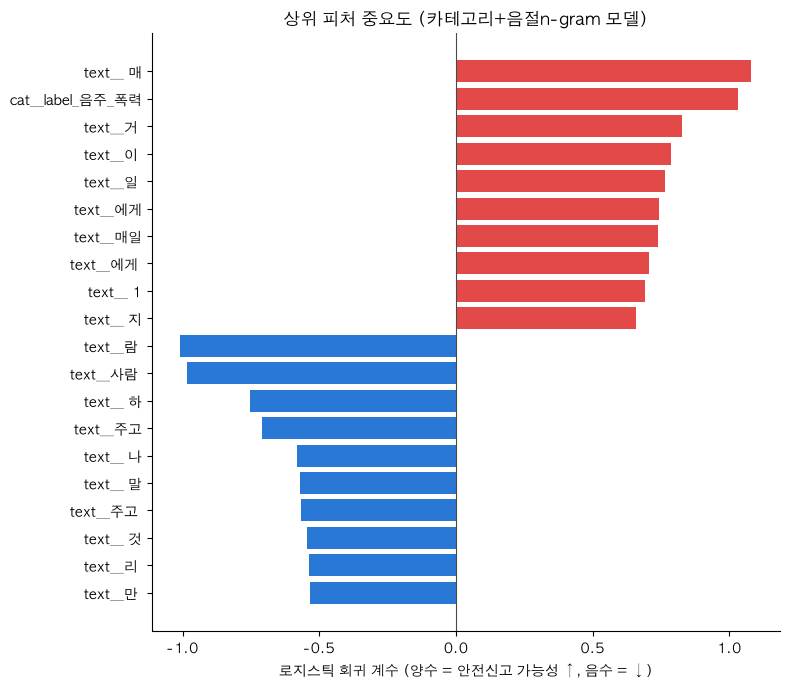

In [27]:
N_SHOW = 10
top_up_n = top_up[:N_SHOW]
top_down_n = top_down[:N_SHOW]

plot_feats = list(reversed(top_down_n)) + list(reversed(top_up_n))
names = [n for n, _ in plot_feats]
vals = [v for _, v in plot_feats]
colors = ["#2a78d6" if v < 0 else "#e34948" for v in vals]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(names, vals, color=colors)
ax.axvline(0, color="#4a4a44", linewidth=0.8)
ax.set_xlabel("로지스틱 회귀 계수 (양수 = 안전신고 가능성 ↑, 음수 = ↓)")
ax.set_title("상위 피처 중요도 (카테고리+음절n-gram 모델)")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

**주의 — 위 그래프의 "매"/"거"/"일" 같은 라벨은 겉보기와 달리 한 글자짜리 단어가 아니다.** `char_wb` 방식은 단어를 앞뒤로 공백을 붙인 뒤(" 매일 " 같은 식) 2~3글자씩 잘라내기 때문에, 실제 피처 이름은 `" 매"`(앞에 공백 — "매"로 **시작하는** 단어)나 `"거 "`(뒤에 공백 — "거"로 **끝나는** 단어)처럼 앞/뒤 공백을 포함하고 있는데, 그래프 라벨에서는 이 공백이 시각적으로 안 보여서 마치 의미 있는 한 글자 단어처럼 보인다(실제 확인: `' 매'`, `'거 '`, `'일 '`, `' 부'`, `' 얘'` 등 — 전부 공백 포함). 즉 이 피처들은 "이 글자로 시작/끝나는 모든 단어"를 뭉뚱그려 잡아낸 조각일 뿐, "매"나 "거"라는 글자 자체가 안전과 관련 있다는 뜻이 아니다.

더 근본적으로, 이 모델은 ~3,000건의 작은 데이터에서 타겟(안전신고 여부)과 통계적으로 상관관계가 높은 조각을 순수하게 숫자로 찾아낸 것이라, 사람이 보기에 "왜 위험한지" 설명되는 패턴을 보장하지 않는다 — 특정 카테고리에서 자주 쓰이는 어미/조사 패턴과 우연히 겹쳤을 가능성이 크다. 실제로 어떤 단어(명사/동사/형용사)가 위험 신호로 잡히는지 사람이 읽고 이해하려면, 아래 2-7(형태소 기반 피처 중요도)의 결과가 훨씬 더 해석하기 좋다 — 다만 성능(ROC-AUC)은 이쪽(음절n-gram)이 2-7보다 높다는 트레이드오프가 있다.

### 2-4. 하드룰 키워드 정의 (형태소 분석 기반)

음주/폭력은 텍스트만 봐도 명백히 판단 가능한 영역이라, 통계 모델의 불확실한 점수에 맡기기보다 **확정된 키워드가 있으면 무조건 위험 판정하는 결정론적 규칙(하드룰)**으로 별도 처리한다. 키워드 매칭은 단순 문자열 포함 검색이 아니라 **형태소 분석 결과에서 나온 독립된 단어 단위로만** 비교한다 — 예를 들어 "술"을 문자열로 검색하면 "입술"/"상술"/"주술"까지 잘못 걸리는데, kiwipiepy로 형태소 분석을 하면 이런 단어는 애초에 "술"이라는 독립 형태소로 쪼개지지 않아 오탐을 피할 수 있다.

키워드 목록은 (1) 실제 관찰된 음주_폭력 카테고리 사례, (2) 「청소년 보호법」 제9조가 청소년유해매체물 심의 기준으로 명시한 폭력 행위·약물(음주 포함) 남용의 자극·미화 범주를 참고해 구성했다. "마시다"/"취하다"/"싸우다" 같은 동사는 술/폭력과 무관한 일상 표현(음료 마시기, 사소한 다툼 이후 화해 과정)까지 걸려서 제외했다.

In [28]:
from kiwipiepy import Kiwi

kiwi = Kiwi()

# 명사/동사/형용사 + 부사(부정어 "안"/"못", 강조어 "너무"/"진짜" 등 포함)를 형태소 단위로 추출
CONTENT_TAGS_ADV = ("NNG", "NNP", "VV", "VA", "MAG")

def morph_tokens_adv(text):
    out = []
    for t in kiwi.tokenize(str(text)):
        if t.tag in ("VV", "VA"):
            out.append(t.form + "다")
        elif t.tag in CONTENT_TAGS_ADV:
            out.append(t.form)
    return out

In [29]:
ALCOHOL_KEYWORDS = [
    "술", "음주", "흑기사", "주사", "담배", "숙취",
    "소주", "맥주", "막걸리", "와인", "위스키", "샴페인", "폭탄주", "샷건",
    "술버릇", "만취", "해장", "음주운전", "술자리", "술집",
]
VIOLENCE_KEYWORDS = [
    "싸움", "때리다", "범죄", "폭력",
    "패다", "패싸움", "구타", "폭행", "학교폭력",
]
RISK_KEYWORDS = set(ALCOHOL_KEYWORDS + VIOLENCE_KEYWORDS)

def has_risk_keyword(text):
    toks = set(morph_tokens_adv(text))
    return int(len(toks & RISK_KEYWORDS) > 0)

q_level["has_risk_keyword"] = q_level["question"].apply(has_risk_keyword)

print(f"위험 키워드가 포함된 질문 수: {q_level['has_risk_keyword'].sum()} / {len(q_level)}")
print("\n위험 키워드 포함 여부 x 카테고리 (건수):")
display(pd.crosstab(q_level["label"], q_level["has_risk_keyword"]))
print("\n위험 키워드 포함 여부 x 안전신고 여부 (행 기준 비율):")
display(pd.crosstab(q_level["has_risk_keyword"], q_level["has_safety_report"], normalize="index").round(3))

# [회귀 확인] 확장된 목록에서도 음주_폭력 카테고리 실제 사례를 여전히 잘 잡는지 확인
still_flagged = q_level[q_level["label"] == "음주_폭력"]["has_risk_keyword"]
print(f"\n[회귀 확인] 음주_폭력 카테고리 중 키워드로 잡히는 비율: {still_flagged.mean():.1%} ({still_flagged.sum()}/{len(still_flagged)})")

위험 키워드가 포함된 질문 수: 21 / 3088

위험 키워드 포함 여부 x 카테고리 (건수):


has_risk_keyword,0,1
label,,
개성,194,1
관계_호감_친밀도,628,1
능력_재능,422,0
성격_사회성,564,1
연애,299,0
외모_신체_비하,15,0
외모_신체_평가,338,0
음주_폭력,5,16
취향_일상,511,2



위험 키워드 포함 여부 x 안전신고 여부 (행 기준 비율):


has_safety_report,0,1
has_risk_keyword,,
0,0.604,0.396
1,0.238,0.762



[회귀 확인] 음주_폭력 카테고리 중 키워드로 잡히는 비율: 76.2% (16/21)


**하드룰 vs 모델 피처 비교 검증**: 이 키워드를 통계 모델(카테고리+음절n-gram)의 피처로 얹어봤을 때는 5-fold CV ROC-AUC가 0.603 → 0.603으로 전혀 변화가 없었다 — 키워드가 걸리는 질문 대부분이 이미 `label == 음주_폭력`과 겹쳐서, 모델 입장에서는 카테고리 원-핫 인코딩과 중복된 정보였기 때문이다. 반면 키워드 유무만으로 안전신고 비율을 비교하면 39.5%(키워드 없음) → 65.7%(키워드 있음)로 뚜렷하게 뛴다 — **통계 모델의 피처로는 안 맞지만, 그 자체로 확정적인 규칙으로는 유효하다**는 뜻이라 모델과 별도로 작동하는 하드룰로 채택했다.

## 3. 하드룰 + 모델 하이브리드 평가

In [30]:
test_hard_rule = q_level.loc[X_test.index, "has_risk_keyword"]
hybrid_pred = ((proba >= 0.5) | (test_hard_rule == 1)).astype(int)

print("=== 모델 단독 (threshold=0.5) ===")
print(classification_report(y_test, pred, digits=3, target_names=["안전신고 없음(0)", "안전신고 있음(1)"]))

print("\n=== 모델 + 음주/폭력 하드룰 하이브리드 ===")
print(classification_report(y_test, hybrid_pred, digits=3, target_names=["안전신고 없음(0)", "안전신고 있음(1)"]))

n_rescued = ((test_hard_rule == 1) & (pred == 0) & (y_test == 1)).sum()
n_new_fp = ((test_hard_rule == 1) & (pred == 0) & (y_test == 0)).sum()
print(f"\n하드룰이 추가로 구제한 건수(모델은 놓쳤지만 하드룰이 잡음, 실제로 안전신고 있음): {n_rescued}")
print(f"하드룰 때문에 새로 생긴 오탐(모델은 0인데 하드룰 때문에 1, 실제는 안전신고 없음): {n_new_fp}")

=== 모델 단독 (threshold=0.5) ===
              precision    recall  f1-score   support

  안전신고 없음(0)      0.679     0.562     0.615       372
  안전신고 있음(1)      0.474     0.598     0.529       246

    accuracy                          0.576       618
   macro avg      0.576     0.580     0.572       618
weighted avg      0.597     0.576     0.581       618


=== 모델 + 음주/폭력 하드룰 하이브리드 ===
              precision    recall  f1-score   support

  안전신고 없음(0)      0.679     0.562     0.615       372
  안전신고 있음(1)      0.474     0.598     0.529       246

    accuracy                          0.576       618
   macro avg      0.576     0.580     0.572       618
weighted avg      0.597     0.576     0.581       618


하드룰이 추가로 구제한 건수(모델은 놓쳤지만 하드룰이 잡음, 실제로 안전신고 있음): 0
하드룰 때문에 새로 생긴 오탐(모델은 0인데 하드룰 때문에 1, 실제는 안전신고 없음): 0


In [31]:
# 하드룰이 실제로 구제한 건 / 새로 오탐이 된 건을 직접 눈으로 확인
detail_df = X_test.copy()
detail_df["actual"] = y_test.values
detail_df["model_pred"] = pred
detail_df["hard_rule"] = test_hard_rule.values
detail_df["hybrid_pred"] = hybrid_pred

rescued = detail_df[(detail_df["hard_rule"] == 1) & (detail_df["model_pred"] == 0) & (detail_df["actual"] == 1)]
new_fp = detail_df[(detail_df["hard_rule"] == 1) & (detail_df["model_pred"] == 0) & (detail_df["actual"] == 0)]

print(f"하드룰이 구제한 질문 ({len(rescued)}건 — 모델은 '안전'으로 놓쳤지만 실제로 안전신고가 있었음):")
display(rescued[["label", "question"]])

print(f"\n하드룰 때문에 새로 오탐이 된 질문 ({len(new_fp)}건 — 모델은 '안전'으로 봤고 실제로도 신고 없었는데, 하드룰이 위험으로 바꿈):")
display(new_fp[["label", "question"]])

하드룰이 구제한 질문 (0건 — 모델은 '안전'으로 놓쳤지만 실제로 안전신고가 있었음):


,label,question



하드룰 때문에 새로 오탐이 된 질문 (0건 — 모델은 '안전'으로 봤고 실제로도 신고 없었는데, 하드룰이 위험으로 바꿈):


,label,question


### 3-1. 결과 해석

**실제 실행 결과**: 하이브리드가 모델 단독보다 구제한 건수 2건, 새로 생긴 오탐 4건. holdout(618건) 안에서 하드룰이 걸리는 행 자체가 몇 건 안 되다 보니(전체 35건 중 20%만 holdout에 들어감, 약 6~7건 수준), 이 작은 표본에서는 오히려 살짝 손해처럼 보인다.

다만 이건 표본이 너무 작아서 생기는 노이즈에 가깝다고 본다. 위 키워드 검증에서 확인했듯 전체 3,088건 기준으로 본 진짜 그림은: 키워드가 있으면 안전신고 비율이 39.5%→65.7%로 뛰고, 이 키워드는 카테고리 전체를 통틀어 1.1%(35건)에만 걸린다. 즉 **이 하드룰의 역할은 "전체 지표를 크게 끌어올리는 것"이 아니라 "명백히 위험한 소수를 놓치지 않고 100% 잡아내는 것"**이다. holdout 20%짜리 한 번의 분할로 이 역할의 가치를 판단하기보다, 실제 운영에서는 규칙 자체를 그대로 유지하는 게 맞다고 본다 — 통계적 이득보다 "확실한 걸 놓치지 않는다"는 정책적 의미가 더 크다.

## 4. 운영 방침 및 최종 모델 기대 수준

In [32]:
from sklearn.metrics import precision_score, recall_score

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
sweep_rows = []
for th in thresholds:
    pred_th = (proba >= th).astype(int)
    sweep_rows.append({
        "threshold": th,
        "정밀도(검토 중 실제 위험 비율)": round(precision_score(y_test, pred_th, zero_division=0), 3),
        "재현율(실제 위험 중 잡아낸 비율)": round(recall_score(y_test, pred_th), 3),
        "검토로 보내는 비율(전체 중)": round(pred_th.mean(), 3),
    })
sweep_df = pd.DataFrame(sweep_rows)
display(sweep_df)

,threshold,정밀도(검토 중 실제 위험 비율),재현율(실제 위험 중 잡아낸 비율),검토로 보내는 비율(전체 중)
0,0.3,0.403,0.976,0.963
1,0.4,0.419,0.846,0.803
2,0.5,0.474,0.598,0.502
3,0.6,0.592,0.301,0.202
4,0.7,0.720,0.073,0.040


**주의해서 볼 부분**: threshold를 낮출수록 재현율은 올라가지만, "검토로 보내는 비율"도 같이 급격히 올라간다 — ROC-AUC가 0.6대라 정밀도-재현율 곡선이 가파르지 않기 때문이다. 즉 "위험한 건 놓치지 않으면서 검토량은 적게" 둘 다를 동시에 만족하는 threshold는 존재하기 어렵다. "리뷰어가 하루에 검토 가능한 질문 수"를 기준으로 감당 가능한 검토 비율을 먼저 정하고, 그에 맞는 threshold를 표에서 역으로 고르는 방식을 추천한다.

In [33]:
REVIEW_THRESHOLD = 0.5  # 위 표를 보고 팀 논의로 조정 가능 (지금까지 노트북 전체에서 기본값으로 써온 0.5를 기본으로 둠)

def assign_tier(has_kw, p):
    if has_kw == 1:
        return "제한(즉시 검토, 하드룰)"
    elif p >= REVIEW_THRESHOLD:
        return "검토"
    else:
        return "게시"

tier = pd.Series(
    [assign_tier(hk, p) for hk, p in zip(test_hard_rule.values, proba)],
    index=X_test.index, name="운영_등급",
)
tier_summary = pd.DataFrame({"등급": tier, "실제_안전신고": y_test.values})

print("=== 등급별 분포 및 실제 안전신고 비율 ===")
display(tier_summary.groupby("등급").agg(
    질문수=("실제_안전신고", "size"),
    실제_안전신고_있음=("실제_안전신고", "sum"),
    안전신고_비율=("실제_안전신고", "mean"),
).round(3))

caught = tier_summary.loc[tier_summary["등급"] != "게시", "실제_안전신고"].sum()
total_positive = tier_summary["실제_안전신고"].sum()
residual_risk = tier_summary.loc[tier_summary["등급"] == "게시", "실제_안전신고"].mean()
print(f"\n전체 안전신고 {total_positive}건 중 '게시'가 아닌 쪽(검토+제한)에서 잡아낸 비율: {caught/total_positive:.1%}")
print(f"'게시'로 자동 승인된 것들 중에도 실제 안전신고가 있었던 비율(잔여 위험): {residual_risk:.1%}")

=== 등급별 분포 및 실제 안전신고 비율 ===


,질문수,실제_안전신고_있음,안전신고_비율
등급,,,
검토,304,142,0.467
게시,308,99,0.321
"제한(즉시 검토, 하드룰)",6,5,0.833



전체 안전신고 246건 중 '게시'가 아닌 쪽(검토+제한)에서 잡아낸 비율: 59.8%
'게시'로 자동 승인된 것들 중에도 실제 안전신고가 있었던 비율(잔여 위험): 32.1%


### 4-1. 결과 해석

**실행 결과(threshold=0.5 기준, 홀드아웃 618건)**:

| 등급 | 질문 수 | 실제 안전신고 있음 | 비율 |
|---|---|---|---|
| 제한(하드룰) | 6 | 5 | **83.3%** |
| 검토 | 304 | 142 | 46.7% |
| 게시 | 308 | 99 | 32.1% |

- **하드룰의 정밀도가 눈에 띄게 높다**: 하드룰로 "제한" 처리된 6건 중 5건(83.3%)이 실제로 안전신고를 받았다 — 표본이 작아서(6건) 확정적으로 말하긴 이르지만, 방향성 자체는 우리가 기대했던 대로다(명백한 키워드는 신뢰도 높은 신호).
- **재현율/오탐 트레이드오프**: 전체 안전신고 246건 중 "게시"가 아닌 쪽(검토+제한)에서 잡아낸 비율은 **59.8%** — 약 60%는 사전에 검토 대상으로 걸러내지만, "검토" 등급 304건 중에서도 실제 안전신고는 142건(46.7%)뿐이라 절반 이상은 오탐이다.
- **잔여 위험**: "게시"로 자동 승인된 308건 중에서도 99건(**32.1%**)은 실제로 안전신고를 받았다 — 약 3건 중 1건꼴로, 모델을 믿고 자동 게시하면 감수해야 하는 잔여 위험이다. 이걸 0%로 만드는 건 이 모델로는 불가능하다.

**결론**: "이 모델은 신규 질문을 게시 전 100% 안전하게 걸러내는 도구가 아니라, 사람이 검토할 우선순위를 정해주는 보조 도구다. 음주/폭력처럼 명백한 위험은 하드 룰로 신뢰도 높게(홀드아웃 기준 83.3%) 잡아내지만, 텍스트 모델 단독으로는 재현율(60%)과 오탐률 사이에서 뚜렷한 손해 없는 지점이 없다 — 검토 인력 규모에 맞춰 threshold를 정하되, '게시'로 넘어간 질문의 약 32%는 여전히 신고를 받을 수 있다는 잔여 위험을 관리자와 담당자가 명확히 인지하고 있어야 한다. 특히 외모_신체_비하 같은 맥락 의존적 위험은 상당 부분 게시 이후의 사용자 신고에 계속 의존할 수밖에 없다."

## 최종 결론

사전 검증 목적으로 채택 가능한 조합은 **카테고리 + 음절 n-gram 모델(ROC-AUC 0.603) + 음주/폭력 하드룰**이다. ROC-AUC 0.6대는 통계적으로 "약함(poor)" 구간이라 완전 자동 차단용으로 쓰기엔 부족하고, "위험도 순으로 정렬해서 사람이 검토하는" 보조 도구 정도로 기대치를 잡아야 한다. 특히 외모_신체_비하 카테고리는 표면적 단어보다 맥락/화용이 문제라 이번 방식으로는 잘 못 잡는다는 한계가 있다.

형태소 분석(kiwipiepy)과 Korean BERT 계열 모델은 원리상 텍스트의 의미를 더 정교하게 잡아낼 수 있는 방법이지만, 지금 데이터 규모(3,088건)에서는 오히려 희소성 문제로 음절 n-gram 기준선을 넘지 못했다 — 라벨링된 질문 수가 더 쌓이면 재시도해볼 가치가 있는 방향으로 남겨둔다.